# Micrograd
https://www.youtube.com/watch?v=VMj-3S1tku0

Micrograd is an autograd engine that implement backpropagation.
BP allow the evaluation of the gradient of a loss function w.r.t. the weights of a NN layer.

This allows the iterative update of the NN weights.
Improving the accuracy of the models.

The 2 inputs of an operations are going to be stored in a single object.
The methematical expressions (different operations) will transform the 2 operands through multiple steps.

The 2 inputs will define a computational graph.

Micrograd builds the computational graph in the background.

C will have 2 childs in the graph (A,B).


The **forward pass** allows to access the value of the last node (g) of the computation.

g can be used to call the backward operation.

In [229]:
import math

In [230]:
from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f

print(f'{g.data:.4f}')
g.backward()
print(f'{a.grad:.4f}')   # prints dg/da
print(f'{b.grad:.4f}')   # prints dg/db

24.7041
138.8338
645.5773


Propagation starts from G backwards applying the chain rule from calculus.
It computes the detrivative of the results wrt to both the initial values.

The computed value will show the weight of each initial value (the amount of change in the final results when a single value is tweaked).

NN takes input and weights as input and applies mathematical expressions to them. Backpropagation is a technique that has applications and sense beyond just NNs.

Micrograd works down to individual scalars. An Example for understanding but with the same principle that can be used for NNs. 

The fundamental mechanism is actually very simple and the most complicated coponents are related to the efficiency of the process.

In [231]:
import math
import numpy as np
import matplotlib.pyplot as plt

First use a single scalar function

In [232]:
def f(x):
    return 3*x**2 - 4*x + 5

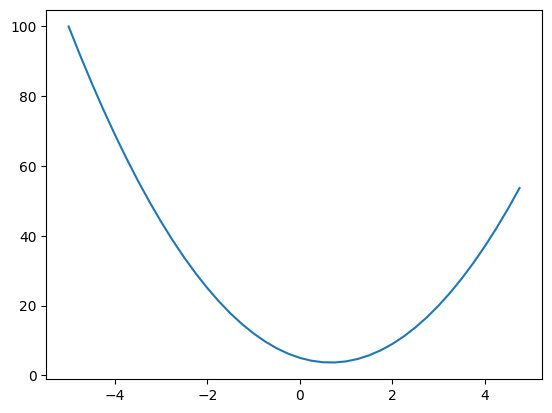

In [233]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

### Derivative

The derivative of the function at each point is the value of the slope. At each point how much a small change in a direction impacts the value of the function?

In [234]:
# Numerical approximation of the slope

h = 0.001
x = 3.0
(f(x+h) - f(x))/h

14.00300000000243

The sign of the slope indicates if the function is growing or decreasing in that point.


### 3 scalar function example

The 3 scalar values are input for the derivative graph

In [235]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


We fix the size of the derivative step again and we evaluate the value of the derivative w.r.t. each single scalar input in the point marked by *d*.

(e.g.) Compute the value of the function for a set of input values, incerase a single one by the step, compute the value again.

In [236]:
# derivative step size
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1:', d1)
print('d2:', d2)
print('slope:', (d2 -d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


In this case increasing *a* have have a negative slope value. (Multiplied by a negative value).

The opposite happens when increasing the value of *b* or *c*.


 

## Neural networks

Neural networks are more complicated and the operators have bigger size (tensors), therefore we will require the definition of data structure.


### Value Class


**Value object**: taks as input to contructor a single scalar value. We will need to define: 
+ ***operators***: representation and arithmetics
+ ***children***: set of children. Input is a tuple for convenience but mantained as a set for mantainance.
+ ***op***: operation that created the Value object



+ ***label***: label for the graph representation
+ ***grad***: holds the value of the gradient operation of the last Value node w.r.t. the current Value

In [237]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None
    
    
    #print()
    def __repr__(self):
        return f"Value(data={self.data})"
    
    
    #+
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #allows addition of numbers
        out = Value(self.data + other.data, (self,other), "+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #allows multiplication with numbers
        out = Value(self.data * other.data, (self, other), "*")
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other )
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "only supporting int/float powers"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out    
    
    def tanh(self):
        x = self.data   
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
        
        
    def backward(self):
         
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:    
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

In [238]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')

# (a.__mul__(b)).__add__(c)
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
#d.__repr__()
print(d)


f = Value(-2.0, label="f")
L = d * f; L.label = "L"

print(L)

Value(data=4.0)
Value(data=-8.0)


**children:** The Value object 
resulted from an operation will store the operators, this will help building the computational graph.

In [239]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

**op:** stores the operation that created the Value object

In [240]:
d._op

'+'

### Visualization

The **draw_dot** function helps showing the structure of the graph leveraging graph_viz library.

In [241]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v)) 
                build(child)
    
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})  
    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        # Rectangular 'record' node for any value in the graph
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape ='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid) 
        
    for n1, n2 in edges:
            dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot
        

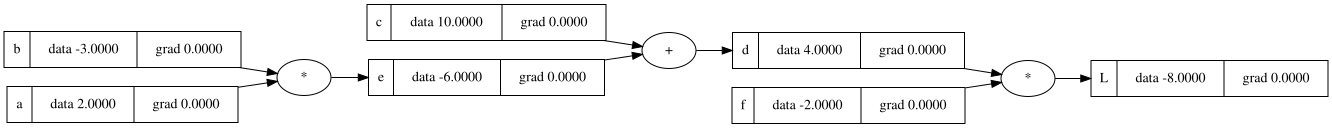

In [242]:
draw_dot(L)

This allows the computation and the representation of the forward pass. That we can later to copmute backpropagation starting from the last Value node.

**Backpropagation** will consists in the computation of the gradient wrt each single value of this chain: dL/dL, dL/dD, ...

In  neural networks these values will be the weights of each node of the network. The copmutation of the gradient wrt the data will not as interesting since the data is going to be fixed anyway.

### Grad (Manual computation)

A **grad** variable in each Value will hoold the value of the derivative of the last computed Value class with respect to it.
 
This will be 0 initialized as in the beginning no operation could affect it.

The gradient is assumed 0 by deafult (as its value would not affect the loss function).



At first we manually define the values of the gradient by estimating the values.

This examples shows how the gradient of L is copmuted w.r.t. the input a.

In [243]:
def manual_grad():
    
    h = 0.0001
    
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # Add a step to a in order to compute dL/da
    a = Value(2.0 + h, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2-L1)/h)
    
manual_grad()   #dL/da


6.000000000021544


In [244]:
L.grad = 1

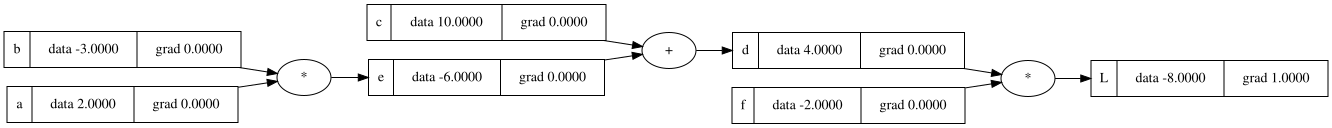

In [245]:
draw_dot(L)

If we want to compute dL/dd (which is going to be simply d) we need to compute:
1. L = d * f
2. ... simple derivative of a product ...

In [246]:
f.grad = 4.0  #the value of d
d.grad = -2.0 #the value of f

**Gradient check** can be used to verify the correctness of the gradient operation.

It can be achieve in this case by modifying manually the manual_grad() function by changing the value of each node by adding h. (One at a time).

The following step is actual backpropagation (dL/dc and dL/de), for measuring the L sensibility to the value changes of these 2 variables.

**Local derivatives**

We are going to compute first *dd/dc*.

Being *d = c + e* this will be symbolically 1.

(f(x+h) - f(x))/h will become:
((c+h) + e) - (c + e)/h -> h/h -> 1.0

The other derivative dd/de is also going to be 1. 

The full gradient would be obtained through the composition of all the computed local derivatives. Each node has not awareness of its location within the graph.

The complete gradient would be obtained through the application of the **chain rule**.

The composition of 2 derivatives can be obtained (at least in these case) through their multiplication.

We want now to compute dL/dc.

We have already computed dL/dd and dd/dc. The application of the chain rule would be in this case:

$$\frac{dL}{dc} = \frac{dL}{dd} * \frac{dd}{dc}$$

The plus node will just *route* the derivative, since the local derivative of the sum is simply 1.
Therefore we will have:

In [247]:
c.grad = -2.0
e.grad = -2.0

dL/de = -2.0
dL/da = (dL/de) * (de/da)

which is going to be computed simply as the first derivative of a product we computed. 

In [248]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

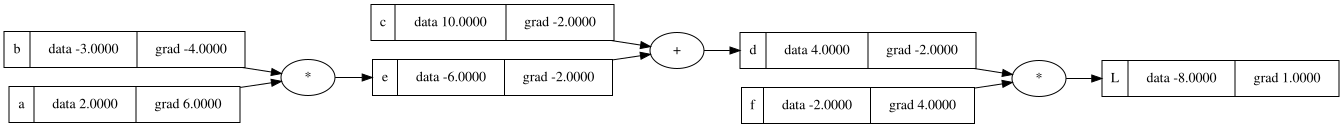

In [249]:
draw_dot(L)

By manually nudging the value of the gradients of each node (and rerunning the forward pass) we should expect to increase the value of the last node L.

In [250]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
d.data += 0.01 * d.grad

# forward pass
e = a * b
d = e + c
L = d * f

### Neuron Backpropagation

This consists in the basic building block for MLP.
Each neuron has weights for the input and a bias (that makes it generally mor prone to firing).

In this example we are going to use the **tanh function** as activation function.

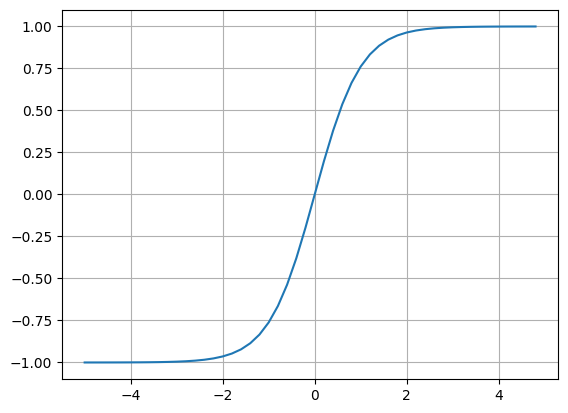

In [251]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

We consider now a 2 neurons MLP

In [252]:
# Neuron inputs: x1,w1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Neuron weights: w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias: b
b = Value(6.7, label='b')

# x1w1 + x2w2 +b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

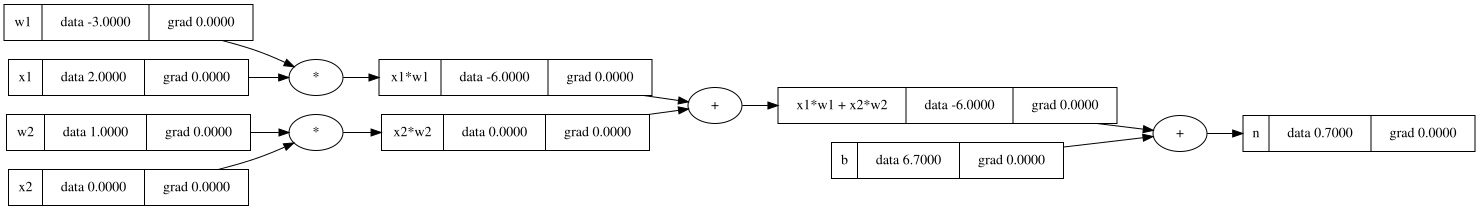

In [253]:
draw_dot(n)

We can also add now the activation function to the output.

The definition of tanh requires however the implementation of tanh, that cannot only be based on + and *, but requires exp() since:

$$tanh = \frac{e^{2x}-1}{e^{2x}+1}$$

The definition of the function is not actually as important as the possibility to compute its local derivative for the backward computation of the gradient.

In [254]:
# def tanh():
#     n = self.data   
#     t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
#     out = Value(t, (self, ), 'tanh')
#     return out

We can now teast the value of the gradient of the full neuron implementation (with the added tanh).

In [255]:
# Neuron inputs: x1,w1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Neuron weights: w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias: b
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 +b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'


# tanh
o = n.tanh(); o.label = 'o'

We are noe going to compute the derivative of o w.r.t. all the 4 inputs (x1,w1,x2,w2), with paricular attention to the weights.

In [256]:
o.grad = 1.0

In order to propagate the gradient though tnah activation function we only need to know the local value of the derivative.

o = tanh(n)

We can use the expression of the derivative and directly compute it with the same value:

$$\frac{d}{dx} = 1 - tanh(n)^2 = 1 - o^2$$

Which has the following value:

In [257]:
1 - o.data**2
n.grad = 0.5

In [258]:
# + operation: (w1x1 + w2x2) '+' b
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [259]:
# another + operation
x1w1.grad = 0.5
x2w2.grad = 0.5

In [260]:
# 2 * operations
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

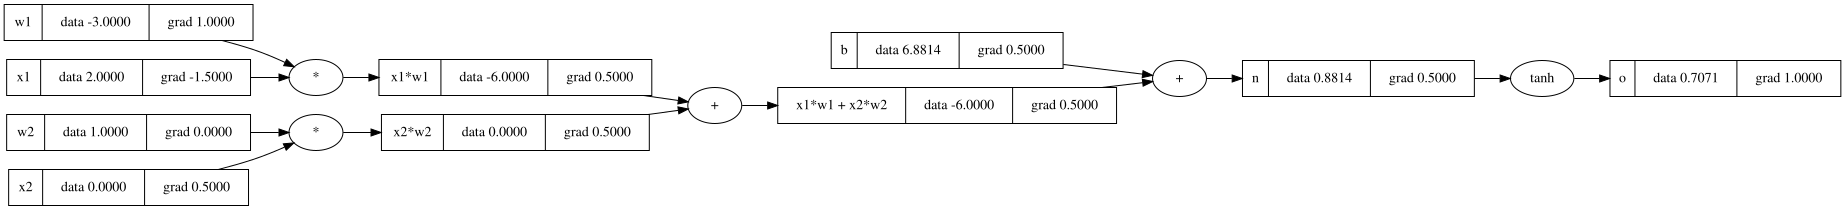

In [261]:
draw_dot(o)

### Backward function

In order to automate the computation of the gradients we need to add to the Value class a **_backward** function parameter.

This will store the way the outputs are going to be chained to the inputs. By default it will be an empty *lambda function*.

The single functions (+, *, tanh, ...) will also implement the backwards function that propagate the gradient.

By doing this the operation for computing the backward gradient will be stored at the same time as the forward pass is executed.

Instead of computing each step manually we can now just call all the defined backward functions in the correct order: 

In [262]:
# Resetting the values with a forward pass

# Neuron inputs: x1,w1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Neuron weights: w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias: b
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 +b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'


# tanh
o = n.tanh(); o.label = 'o'

In [263]:
o.grad = 1.0

o._backward()
n._backward()
b._backward() # Initialized as an empty function
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

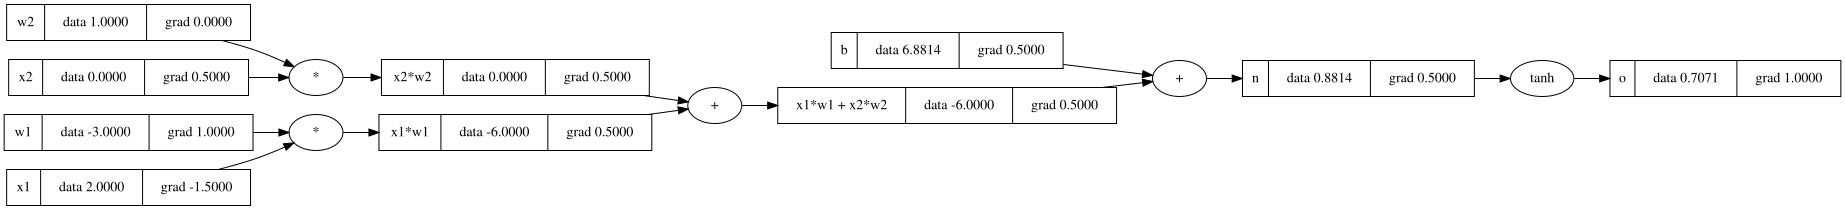

In [264]:
draw_dot(o)

In order to also avoid the manual call to the single backward() functions.

This will require the definition of an ordering for the operations that can be achieved through the use of **topological sort**: laying out a graphs in a way that the edges only go backwards.

This ensures that a node gets pushed to the list only after all of its children nodes.

In [265]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:    
            build_topo(child)
        topo.append(v)

In [266]:
o.grad = 1.0
build_topo(o)

Invert the topological order and call the backward function for each node of the list.

In [267]:
# for node in reversed(topo):
#     node._backward()

This will be defined in the Value class as a single function to be called.

In [268]:
o.backward()

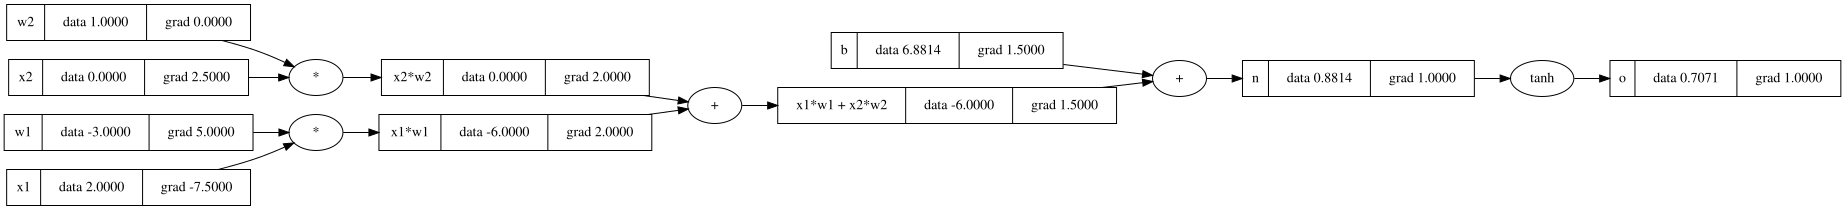

In [269]:
draw_dot(o)

#### Bug

*BUG fixed: to reproduce it change the += in backward function within the value class to =*

Calling backward on the sum of two istances of the same node. The derivative should in this case be the sum of the number of element of nodes (2) instead of just 1.

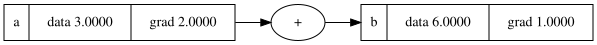

In [270]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b' 
b.backward()
draw_dot(b)

In this other case the gradient would be overwritten due to the use of the nodes in multiple functions.

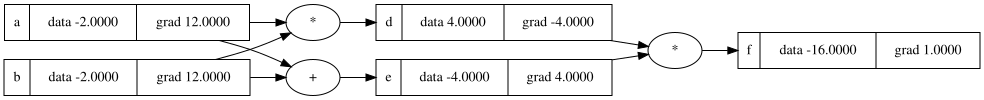

In [271]:
a = Value(-2.0, label='a')
b = Value(-2.0, label='b')
d = a * b   ;   d.label = 'd'
e = a + b   ;   e.label = 'e'
f = d * e   ;   f.label = 'f'

f.backward()
draw_dot(f)

This bug generally arises with the use of multiple instances of the same node and needs the use of the **multivariate derivative** for it to be fixed.

In order to achieve this fix we need to add the **gradient accumulation**.

This way each time a backward operation is computed the previous ones are not going to be overwritten but added to each other.

#### rmul


Current implementation does not allows addition and multiplication of number types (that are not wrapped in a Value() class).

out = Value(self.data + other.data, (self,other), "+") allows the sum and the multiplication with an integer as th eright operator but not as a left one

3.\__mul__ (a) type is still not allowed.

This would require the definition of the ***__rmul__*** operator, that will provide as a fallback the swapped operation.

rmul (other * self) = self * other

#### Test: change the tanh implementation

In order to change the implementation of the tanh function, we start from the definition of the *exponential* function and the *division*.

Instead of the division we can implement the inversion of the Value node, therefore the *elevation to constant* operation (-1 in this case) would be much more useful.

The *subtraction* is also defined for the subdivision of the tanh function. (Requires also the *negative* operator).

The graph would be longer than the previous verions, but with equivalent operations that leads to the same result.

In [272]:
# Neuron inputs: x1,w1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Neuron weights: w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias: b
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 +b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# activation: tanh full implementation
# o = n.tanh(); o.label = 'o'

e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()

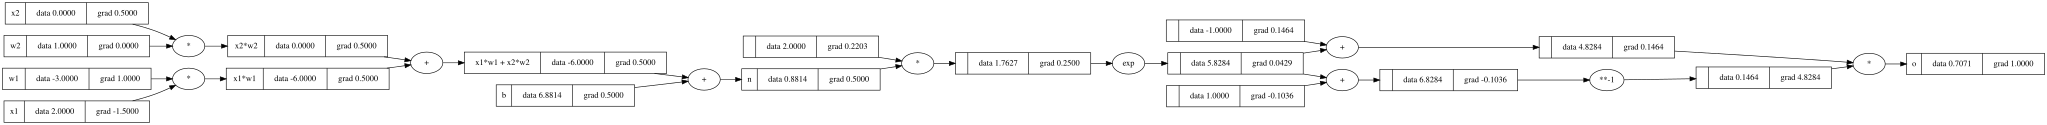

In [273]:
draw_dot(o)

This highlight the possibility of implementing backward proppagation at any level of precision, it does not matter which kind of operation you are using as long as you can compute the local gradient.

### Pytorch

In [274]:
import torch

x1 = torch.Tensor([2.0]).double();                x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();                x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();               w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();                w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double();  b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


Differently from micrograd pytorch uses tensors instead of scalar values like micrograd.

Tensors also have both *data* and *grad* attributes.

In [275]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

## Neural networks

Using the introduced tools we can start building simple neural networks (matching the torch api) 

In [276]:
import random

**Neuron**: defines the call operator that applies the neuron operation to alist of values (neuron inputs)

In [277]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        # w*x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) #starts the sum from self.b
        out = act.tanh()
        return out


**Layer**: each layer has a set of independent neurons (all connected to all the inputs of the previous layer). 

In [278]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

**MLP**: layers feeds into each other sequentially.

In [279]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [280]:
x = [2.0, 3.0, -1.0]  #inputs
n = MLP(3, [4,4,1])  #MLP: inputs, layers(2 hidden, 1 output)
n(x)  #forward pass

Value(data=0.31270202898478827)

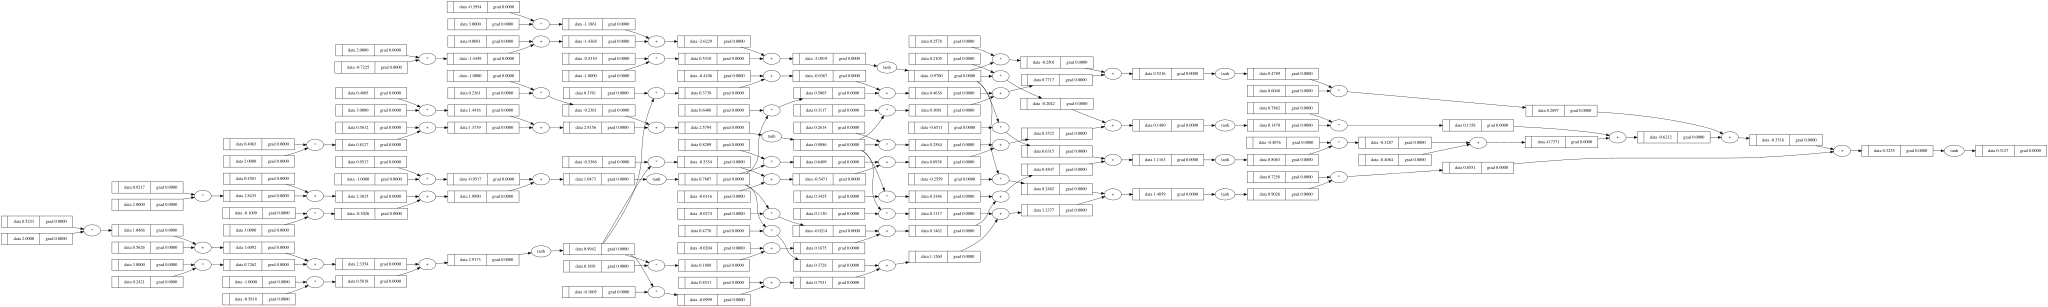

In [281]:
draw_dot(n(x))

We can now use micrograd to compute the backward gradient of a MLP, with the use of a set of examples.

In [ ]:
xs = [
    [2.0, 3.0, -1,0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, -1.0]

1.51